In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from rich.progress import Progress
from rich.console import Console
import sys
import datetime



med = pd.read_csv('data/Medicine_Details.csv')

med.head()

,Medicine Name,Composition,Uses,Side_effects,Image URL,Manufacturer,Excellent Review %,Average Review %,Poor Review %
0,Avastin 400mg Injection,Bevacizumab (400mg),Cancer of colon and rectum Non-small cell lun...,Rectal bleeding Taste change Headache Noseblee...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Roche Products India Pvt Ltd,22,56,22
1,Augmentin 625 Duo Tablet,Amoxycillin (500mg) + Clavulanic Acid (125mg),Treatment of Bacterial infections,Vomiting Nausea Diarrhea Mucocutaneous candidi...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glaxo SmithKline Pharmaceuticals Ltd,47,35,18
2,Azithral 500 Tablet,Azithromycin (500mg),Treatment of Bacterial infections,Nausea Abdominal pain Diarrhea,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Alembic Pharmaceuticals Ltd,39,40,21
3,Ascoril LS Syrup,Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml)...,Treatment of Cough with mucus,Nausea Vomiting Diarrhea Upset stomach Stomach...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glenmark Pharmaceuticals Ltd,24,41,35
4,Aciloc 150 Tablet,Ranitidine (150mg),Treatment of Gastroesophageal reflux disease (...,Headache Diarrhea Gastrointestinal disturbance,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Cadila Pharmaceuticals Ltd,34,37,29


In [2]:
med.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11825 entries, 0 to 11824
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Medicine Name       11825 non-null  object
 1   Composition         11825 non-null  object
 2   Uses                11825 non-null  object
 3   Side_effects        11825 non-null  object
 4   Image URL           11825 non-null  object
 5   Manufacturer        11825 non-null  object
 6   Excellent Review %  11825 non-null  int64 
 7   Average Review %    11825 non-null  int64 
 8   Poor Review %       11825 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 831.6+ KB


In [ ]:
#preprocessing the data
med.duplicated().sum()  # 84 duplicates was found

med.isnull().sum()   # no null values

Medicine Name         0
Composition           0
Uses                  0
Side_effects          0
Image URL             0
Manufacturer          0
Excellent Review %    0
Average Review %      0
Poor Review %         0
dtype: int64

In [4]:
#dropping duplicates
med.drop_duplicates(inplace=True)

In [5]:
med.duplicated().sum() # checking after dropping duplicates , got 0 left 

0

In [ ]:
#encoding the data. we need numerical values for ML model 
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
med['Medicine Name'] = encoder.fit_transform(med['Medicine Name']) # changing the medicine name to numerical values ( randomly chosen by me)
med['Manufacturer'] = encoder.fit_transform(med['Manufacturer']) # changing the manufacturer name to numerical values  ( randomly chosen by me)

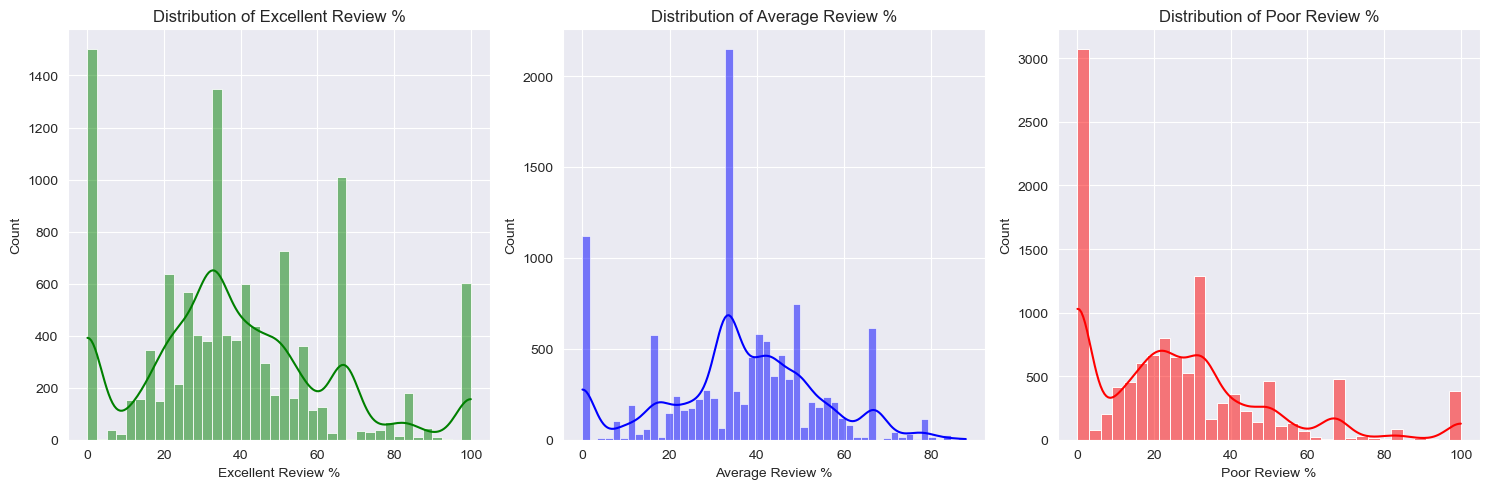

In [7]:
#EDA ( exploratory data analysis)

#checking the distribution of the data 

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid') # setting the style of the plot

fig, ax = plt.subplots(1,3, figsize=(15,5)) # creating a figure with 2 subplots

sns.histplot(med['Excellent Review %'],kde =True, ax=ax[0], color='green') # plotting the histogram of the excellent review percentage
ax[0].set_title('Distribution of Excellent Review %')

sns.histplot(med['Average Review %'],kde =True, ax=ax[1], color='blue') # plotting the histogram of the average review percentage
ax[1].set_title('Distribution of Average Review %')

sns.histplot(med['Poor Review %'],kde =True, color='red') # plotting the histogram of the poor review percentage    
ax[2].set_title('Distribution of Poor Review %')    

plt.tight_layout()
plt.show()

In [8]:
manufacturer_counts = med['Manufacturer'].value_counts()  # there was too many value for interactive plot so i used value_counts to get the count of each manufacturer and then plot it
print(manufacturer_counts.head())  # Print the first few counts to inspect


Manufacturer
638    819
321    648
151    569
674    441
389    432
Name: count, dtype: int64


In [9]:
import plotly.express as px

# Plotting the number of medicines by manufacturer
fig = px.bar(manufacturer_counts, x=manufacturer_counts.index, y=manufacturer_counts.values, 
             title='Number Of Medicines by Manufacturer')

# Rotate x-axis labels for readability
fig.update_xaxes(tickangle=45)
fig.update_layout(xaxis_title='Manufacturer', yaxis_title='Number of Medicines')

# Show the figure
fig.show()


Text(0.5, 0, 'Poor Review %')


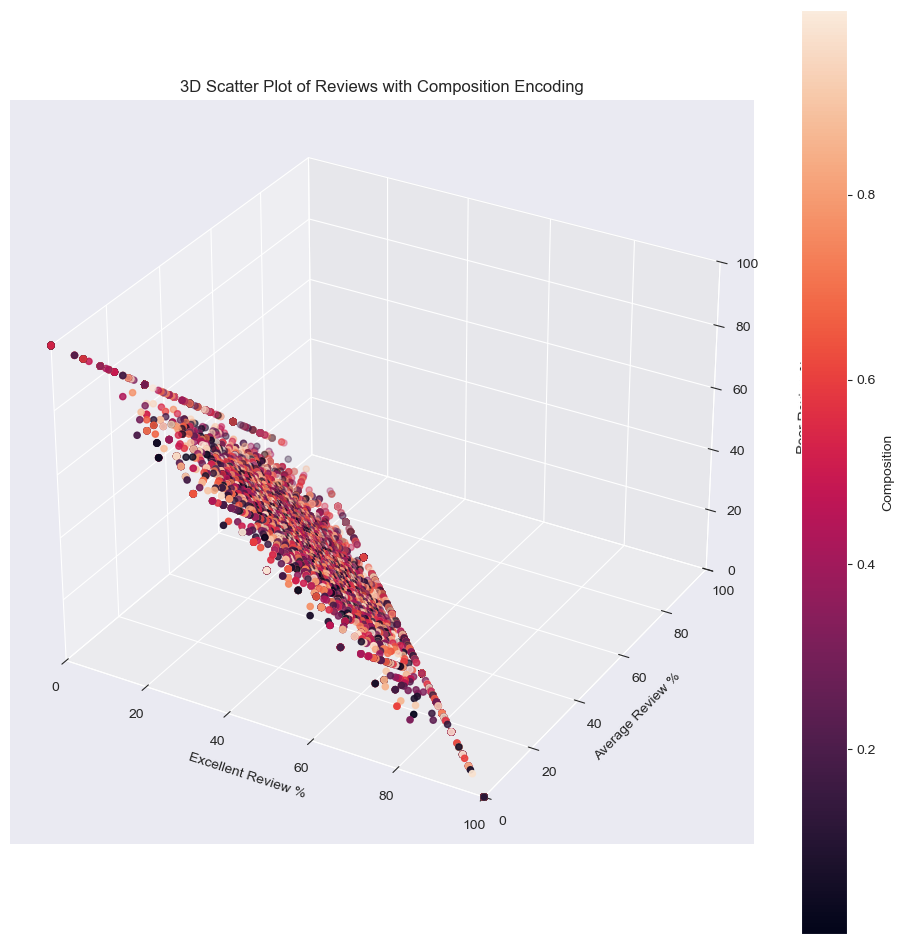

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# You might want to encode the 'Composition' text to numeric values for better visualization
# For example, using a label encoder or assigning colors based on categories

fig = plt.figure(figsize=(12,12))  # creating a figure
ax = fig.add_subplot(111, projection='3d')  # adding a 3d subplot

# Create a color map for 'Composition', assuming Composition is a categorical column
# For simplicity, let's create a random color map (you might want a proper encoding)
colors = np.random.rand(len(med))  # Random color values for illustration

# Plot the scatter plot with color based on the composition
sc = ax.scatter(med['Excellent Review %'], med['Average Review %'], med['Poor Review %'], c=colors, marker='o')

ax.set_xlim([0, 100])  # Adjust limits for the x-axis
ax.set_ylim([0, 100])  # Adjust limits for the y-axis
ax.set_zlim([0, 100])  # Adjust limits for the z-axis




# Set labels for the axes
ax.set_xlabel('Excellent Review %')
ax.set_ylabel('Average Review %')
ax.set_zlabel('Poor Review %', labelpad=20)

# Add a color bar for reference
plt.colorbar(sc, label='Composition')

print(ax.zaxis.label)  # Check the label of the z-axis


plt.title('3D Scatter Plot of Reviews with Composition Encoding')  # Title of the plot
plt.show()


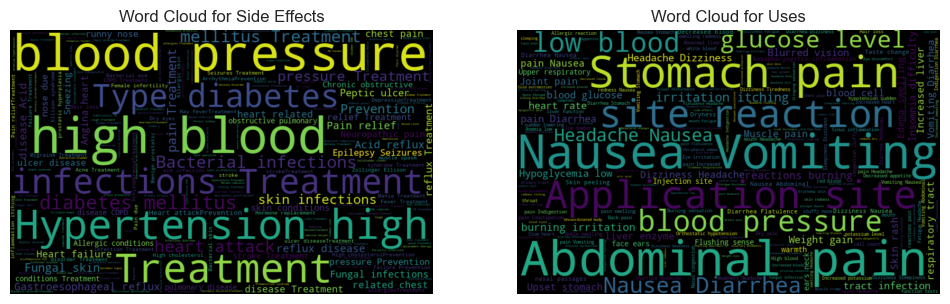

In [11]:
#using natural language processing to find common words 

from wordcloud import WordCloud 

#generating a word cloud for Uses column

text_uses = ' '.join(med['Uses'].values) # Join all the text in the 'Uses' column
wordcloud_uses = WordCloud(width= 800, height = 500, background_color = 'black').generate(text_uses) # Generate the word cloud  

text_side_effects = ' '.join(med['Side_effects'].values) # Join all the text in the 'Side Effects' column
wordcloud_side_effects = WordCloud(width= 800, height = 500, background_color = 'black').generate(text_side_effects) # Generate the word cloud

plt.figure(figsize=(12,7)) # Create a figure
plt.subplot(1,2,1) # Add a subplot  
plt.imshow(wordcloud_uses,interpolation='bilinear') # Display the word cloud for side effects
plt.title('Word Cloud for Side Effects') # Add a title
plt.axis('off') # Turn off axis

plt.subplot(1,2,2) # Add another subplot
plt.imshow(wordcloud_side_effects, interpolation='bilinear') # Display the word cloud for uses
plt.title('Word Cloud for Uses') # Add a title
plt.axis('off') # Turn off axis

plt.show() # Show the plot


In [12]:
#lets do soem ML model to predict the review percentage with random forest regressor


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error  
from sklearn.preprocessing import LabelEncoder   # adding this after getting ValueError: could not convert string to float: 'Itraconazole (1% w/w)'

label_cols= ['Composition', 'Uses', 'Side_effects', 'Manufacturer'] # columns to be label encoded becasue they are in string format
label_encoders = {} # dictionary to store the label encoders    

for col in label_cols: # iterating through the columns
    le = LabelEncoder() # creating a label encoder object
    med[col] = le.fit_transform(med[col]) # fitting and transforming the column
    label_encoders[col] = le # storing the label encoder in the dictionary
    
med = med.drop(columns = ['Image URL']) # dropping the image url column as it is not needed for the model and given error while fitting the model

#preparing feautures and target 
x = med.drop(columns=['Excellent Review %', 'Average Review %', 'Poor Review %']) # thse are the features i am going to use
y = med['Excellent Review %'] # this is the target value(flatted this column due to error)

#splitting the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=12) # splitting the data

#training the model 
model = RandomForestRegressor(n_estimators = 100, random_state= 42) # creating a random forest regressor model
model.fit(x_train, y_train) # fitting the model

#predicting the values
y_pred = model.predict(x_test) # predicting the values
mse = mean_squared_error(y_test, y_pred) # calculating the mean squared error
print('Mean Squared Error:', mse) # printing the mean squared error

Mean Squared Error: 673.0605587033666


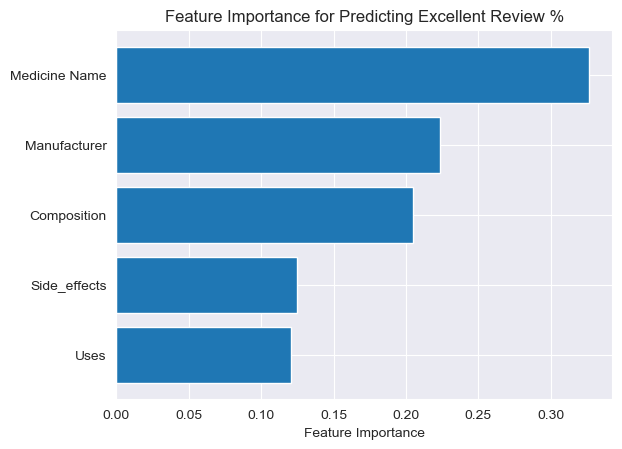

In [14]:
#feauture importance

"'this gives to good understanding of which feautures are important for predicting the excellent review percentage, like medicine name is the most important in here'"

feauture_importances = model.feature_importances_ # getting the feauture importance

sorted_idx = feauture_importances.argsort() # sorting the feauture importance
plt.barh(x.columns[sorted_idx], feauture_importances[sorted_idx]) # plotting the barh plot
plt.xlabel('Feature Importance')  # xlabel
plt.title('Feature Importance for Predicting Excellent Review %') # title
plt.show() # showing the plot

In [16]:
#lets do a cross validation to get a better understanding of the model

from sklearn.model_selection import cross_val_score # importing the cross val score

cv_scores = cross_val_score(model, x, y, cv=5, scoring='neg_mean_squared_error') # getting the cross val score
print(f'Cross-validated mean squared error: {-cv_scores.mean()} ') # printing the cross val score

Cross-validated mean squared error: 718.6065026059135 


Model tuning

In [17]:
from sklearn.model_selection import GridSearchCV # importing the grid search cv

param_grid = {'n_estimators': [50,100,200],
              'max_depth': [10,20,None],
              'min_samples_split': [2,5,10]} # defining the parameter grid
grid_search = GridSearchCV(RandomForestRegressor(random_state = 42), param_grid , cv =3, scoring='neg_mean_squared_error') # creating a grid search object   )
grid_search.fit(x_train, y_train) # fitting the grid search object

print('Best Parameters:', grid_search.best_params_) # printing the best parameters  

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


In [18]:
#lets add visuals to this preedictions
fig = px.scatter(x=y_test, y=y_pred, labels ={'x': 'True Values', 'y': 'Predicted Values'},
                 title='True vs Predicted Values for Excellent Review %') # creating a scatter plot
fig.show() # showing the plot